In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

In [3]:
path ="C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio"

In [4]:
path ="C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio"

sys.path.append(path + '/Modules')
from avalanches_functions import *
from functions import * 
from plotting_functions import *
import matplotlib
matplotlib.rc('font', **{'family':'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [5]:
path_data = 'C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo'

In [8]:
import os
os.chdir(path_data)

In [6]:
cd D:

D:\


In [7]:
cd new_data_thalamus/

D:\new_data_thalamus


In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 25

In [9]:
import os
import numpy as np
import scipy.signal as ss
import mat73

thalamus = True
start = int(input('insert start'))
if not thalamus:
    rat = 4
    
    file = os.listdir()[1:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data']
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000
    

if thalamus:
    rat = int(input('insert rat'))
    file = os.listdir()[start:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data'][0]
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000


insert start 0
insert rat 0


In [10]:
pwd

'C:\\Users\\Benedetta\\Downloads\\Barrel+Talamo\\Barrel+Talamo'

In [11]:
import os
import numpy as np
import scipy.signal as ss
import scipy.signal as ss
fs = 25000
nTrials = len(indexes)-2
#nTrials = 58
nchan = 30
nchan_c = 27
import scipy.signal as ss
##spikes

fs = 25000
nyq = 0.5*fs
T =int(input('insert T'))

low = 300/nyq
high = 3000/nyq
b,a = ss.butter(2,[low,high], "bandpass")
spikes = ss.filtfilt(b,a,data,axis = 1, padlen=150)
spikes = (spikes - np.mean(spikes,0)) # substracting mean population trend (artifact removal)

spikesTrials = []
if not thalamus:
    for r in range(nTrials):
        spikesTrials.append(spikes[:nchan_c,indexes[r]:indexes[r]+ int(fs*T)])
    spikesTrials = np.array(spikesTrials)
else:
    spikes = (spikes[:nchan])
    for r in range(nTrials):
        spikesTrials.append(spikes[:,indexes[r]:indexes[r]+int(fs*T)])
    spikesTrials = np.array(spikesTrials)


insert T 10


In [12]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 3
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)

In [14]:
spikesTrials.shape, binspikes.shape[2]/25000, T, nTrials, num

((28, 30, 250000), 10.0, 10, 28, 28)

In [15]:
#nTrials2 = nTrials
#nTrials = nTrials2-1
nTrials =binspikes.shape[0]

start_rest,end_rest=2,T
restspikes = concatenat_spikes(binspikes[:,20:],start_rest,end_rest,nTrials, fs=25000)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)


prova_n = restspikes
#inspikes[0].T
N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time
print(mean_interspike_time)
print(np.mean(interspike_time)/25000*1000, np.std(interspike_time)/np.sqrt(len(interspike_time))/25000*1000)

89
3.5494579048283077 0.028769959861893988


In [18]:
S_shape_.shape[0]/25000/8

28.0

In [16]:
def compute_fr_v(data, mean_interspike_time, coef):
    ev = data
    #ev = np.sum(data, axis=1).astype(int)
    T = int(mean_interspike_time * coef)

    cumsum = np.cumsum(np.insert(ev, 0, 0))
    density = (cumsum[T:] - cumsum[:-T]) / T

    # padding finale per mantenere stessa lunghezza
    density = np.concatenate([density, np.zeros(T-1)])

    return density
total_f = np.zeros(binspikes.shape)

for g in range(nTrials):
    for n in range(nch):
        f= compute_fr_v(binspikes[g,n,:], 500,3)
        #plt.plot(f)
        total_f[g,n] = f

In [14]:
total_f.shape,

((28, 30, 250000),)

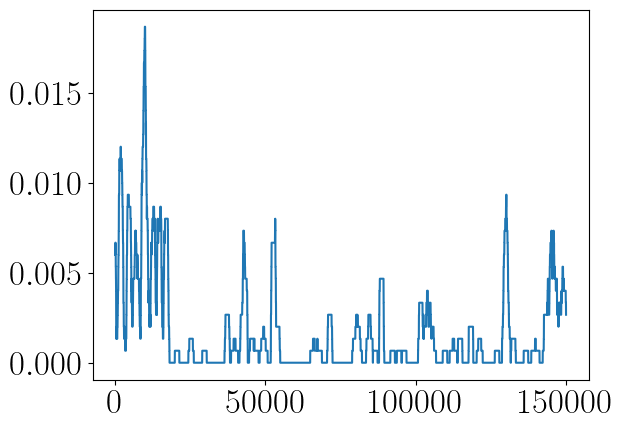

In [14]:
plt.plot(total_f[1,25,25000:25000*7])

## Avalanches distributions

In [19]:
import powerlaw as pwl
import matplotlib.pyplot as plt
import numpy as np
from powerlaw_fit import *
from stats import *
from power import *
from matplotlib import cm

## Spontaneous activity

In [36]:
binspikes.shape[2]/25000

5.0

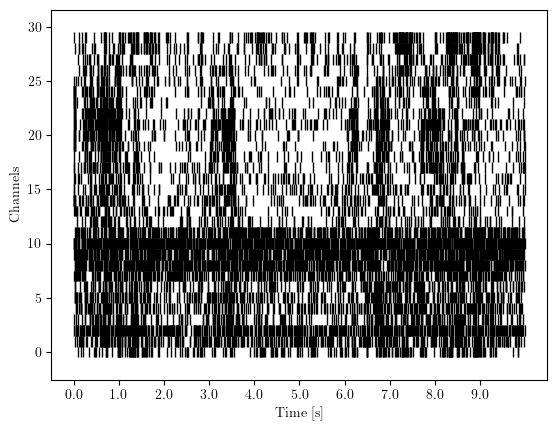

In [17]:

pos = []
trial = 10
for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])

pos = np.asarray(pos)
plt.eventplot(pos, color='black',linewidth=1.);
plt.xlabel('Time [s]')
plt.xticks(np.arange(0,25000*10,25000), labels = np.arange(0,25000*10,25000)/25000)
plt.ylabel('Channels');


In [18]:
plt.rcParams['font.size']

10.0

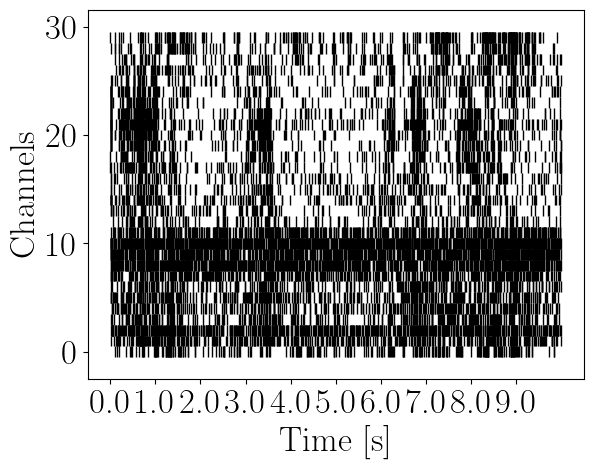

In [28]:

pos = []
trial = 10
for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])
pos = np.asarray(pos)
plt.eventplot(pos, color='black',linewidth=1.);
plt.xlabel('Time [s]')
plt.xticks(np.arange(0,25000*10,25000), labels = np.arange(0,25000*10,25000)/25000)
plt.ylabel('Channels');


In [15]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 3
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)

In [22]:
binspikes.shape[2]/25000, restspikes.shape[0]/25000/8

(10.0, 28.0)

In [31]:
#nTrials2 = nTrials
#nTrials = nTrials2-1
nTrials =binspikes.shape[0]

start_rest,end_rest=2,T
restspikes = concatenat_spikes(binspikes[:,20:],start_rest,end_rest,nTrials, fs=25000)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)

S_shape_ = np.zeros((restspikes.shape[0]))

prova_n = restspikes
#inspikes[0].T
N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time
print(mean_interspike_time)
print(np.mean(interspike_time)/25000*1000, np.std(interspike_time)/np.sqrt(len(interspike_time))/25000*1000)

134
5.370557999817946 0.040727506962775155


In [36]:
(sizes).shape

(7213,)

In [37]:
#nTrials2 = nTrials
#nTrials = nTrials2-1
nTrials =binspikes.shape[0]

start_rest,end_rest=2,T
restspikes = concatenat_spikes(binspikes[:,:12],start_rest,end_rest,nTrials, fs=25000)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)

S_shape_ = np.zeros((restspikes.shape[0]))

prova_n = restspikes
#inspikes[0].T
N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time
print(mean_interspike_time)
print(np.mean(interspike_time)/25000*1000, np.std(interspike_time)/np.sqrt(len(interspike_time))/25000*1000)

69
2.7406311356105415 0.01122897191571695


In [39]:
len(sizes), S_shape.shape

(14717, (64131,))

In [ ]:
### Report mean_interspike_time

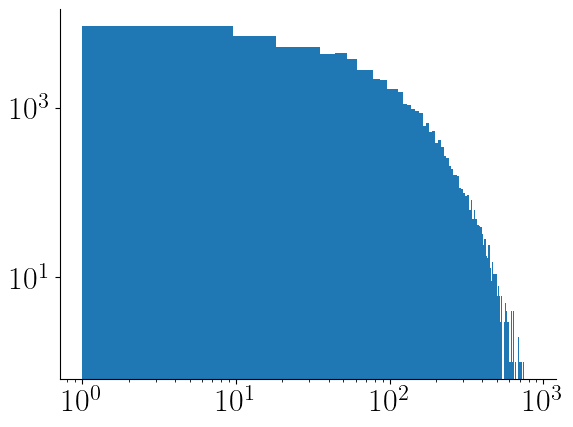

In [118]:
plt.hist(interspike_time, bins = 100);
plt.yscale('log')
plt.xscale('log')

In [21]:
from functions import concatenat_spikes

In [19]:
from plotting_functions import *
from avalanches_functions import *

In [23]:
s = [sizes]
d = [durations]
extrinsic_par = []
h = 0

temp = []
sizes = s[h]
durations = d[h]

xm = max(sizes) if h == 0 else max(sizes)



expo = False
centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(sizes,1,4, xm,'default', expo)
print(xmin)

temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
xm2 = max(durations) if h == 0 else max(durations)

centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(durations,1,4,xm2,'default', expo)
temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
a, b, c, x, inter, pred, errpred, fit, errfit = scaling_new(sizes,durations,1,4,4,
                                                            'default','default','default',
                                                            'default',xm,xm2,'default','default')
print(xmin)
temp.append([sizes, durations, a, b, c, x, inter, pred, errpred, fit, errfit])
extrinsic_par.append(temp)

Calculating best minimal value for power law fit
Nbins estimated are are 22
Alpha is 2.0821119872723126
7.0
Calculating best minimal value for power law fit
Nbins estimated are are 15
Alpha is 2.501678369619889
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Prediction from crackling noise relation: delta =  1.3877558116952524 +- 0.043565443622480625
Fit from of average size given duration points: delta =  1.2953970785537399 +- 0.016320178557992483
3.0


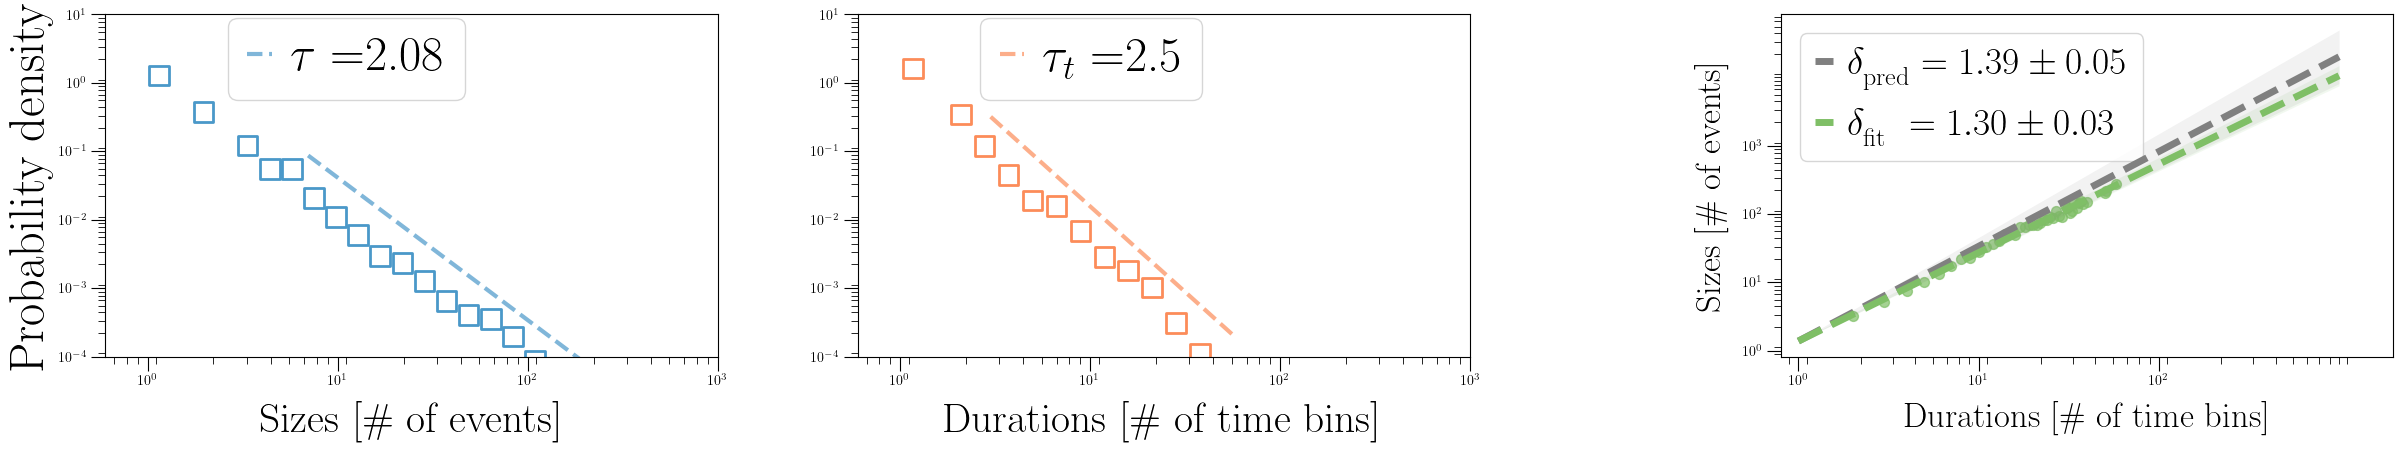

In [24]:

if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
fig,ax = plt.subplots(1,4,figsize = (24,4.5), gridspec_kw={'width_ratios': [1,1,0.05,1]})
color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_par[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_par[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[0].set_xlim(0.6,1000)
    ax[0].set_ylim(0.0001,10)
    ax[0].set_xticks(np.logspace(0,3,4))

    ax[0].set_xlabel(r'Sizes [\# of events]', fontsize = 30, labelpad = 10)
    
    plot_av_statistics(ax[1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_par[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_par[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[1].set_xlim(0.6,500)
    ax[1].set_ylim(0.0001,10)
    ax[1].set_xticks(np.logspace(0,3,4))

    ax[1].set_xlabel(r'Durations [\# of time bins]', fontsize = 30, labelpad = 10)
    
    xmax = 1000
    plot_crackling_noise(ax[3], extrinsic_par[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz, fontsize=25)
  
    ax[3].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 27, loc = 'upper left')


    ax[3].set_xlim(0.8,2000)
    ax[3].set_xticks([1,10,100])
    ax[3].set_yticks([1,10,100,1000])
if not expo: 
    ax[0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
    ax[1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
ax[2].remove()


ax[0].set_ylabel('Probability density', fontsize = 35)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for j in [0,1,3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].xaxis.set_minor_locator(locmin)
    ax[j].xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].yaxis.set_minor_locator(locmin)
    ax[j].yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax[j].tick_params(length = 5, which = 'minor')
    ax[j].tick_params(length = 10)


fig.tight_layout(pad = .6,h_pad = 2)
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
plt.show()

### Avalanches in the thalamus

In [77]:
end_rest

5

In [17]:
#nTrials2 = nTrials
#nTrials = nTrials2-1
#nTrials =28

start_rest,end_rest=2,T
restspikes = concatenat_spikes(binspikes[:,:12],start_rest,end_rest,nTrials, fs=25000)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizesT, durationsT, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)


prova_n = restspikes
#inspikes[0].T
N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time

69

In [52]:
nTrials, binspikes.shape

(58, (58, 30, 125000))

In [18]:
s = [sizesT]
d = [durationsT]
extrinsic_parT = []
h = 0

temp = []
sizes = s[h]
durations = d[h]

xm = max(sizes) if h == 0 else max(sizes)



expo = True
centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(sizes,1,4, xm,'default', expo)
print(xmin)

temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
xm2 = max(durations) if h == 0 else max(durations)

centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(durations,1,4,xm2,'default', expo)
temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
a, b, c, x, inter, pred, errpred, fit, errfit = scaling_new(sizes,durations,1,4,4,
                                                            'default','default','default',
                                                            'default',xm,xm2,'default','default',50,50)
print(xmin)
temp.append([sizes, durations, a, b, c, x, inter, pred, errpred, fit, errfit])
extrinsic_parT.append(temp)

Calculating best minimal value for power law fit
Nbins estimated are are 20
Alpha is 3.699831099926486
11.0
Calculating best minimal value for power law fit
Nbins estimated are are 14
Alpha is 3.2859184819843525
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Prediction from crackling noise relation: delta =  0.8466772066997988 +- 0.029695767176947555
Fit from of average size given duration points: delta =  1.0948682461382482 +- 0.023124924206280064
4.0


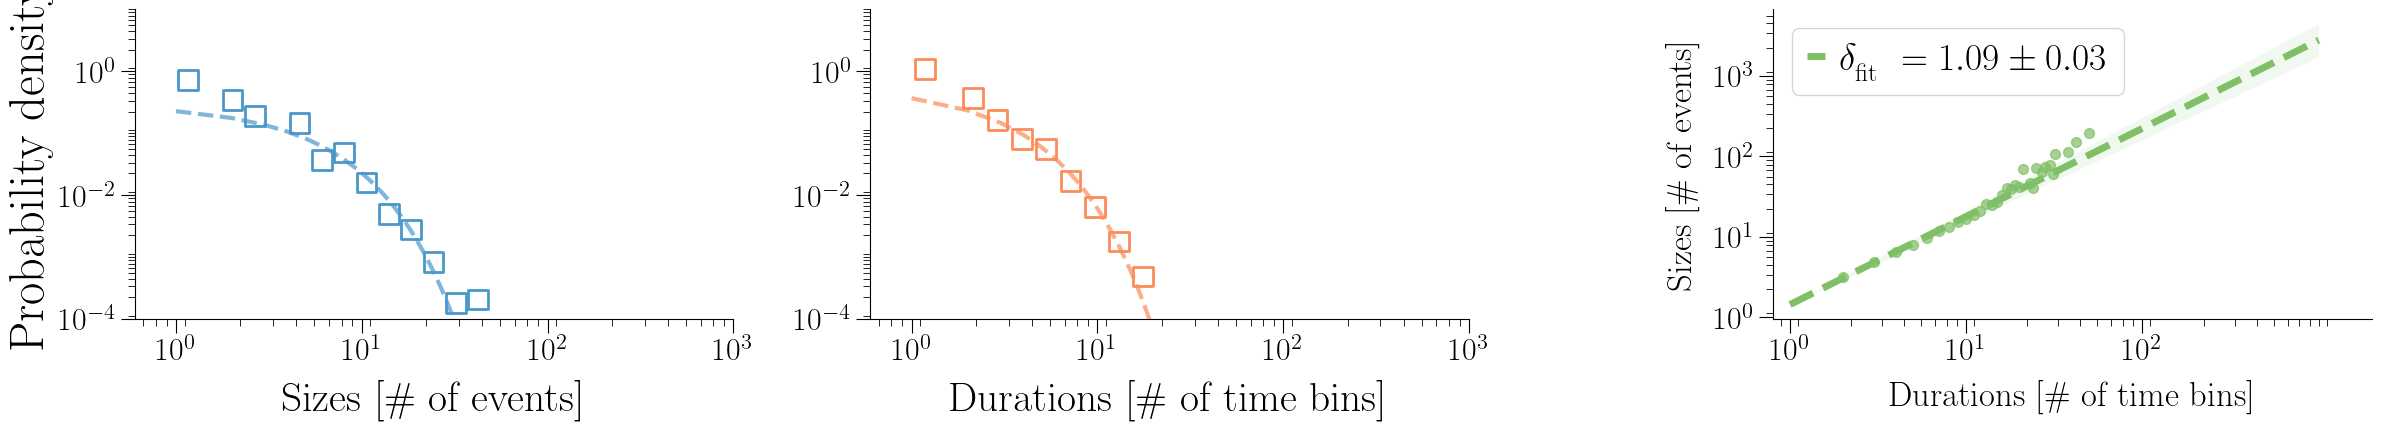

In [87]:

if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
fig,ax = plt.subplots(1,4,figsize = (24,4.5), gridspec_kw={'width_ratios': [1,1,0.05,1]})
color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0], extrinsic_parT[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_parT[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_parT[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[0].set_xlim(0.6,1000)
    ax[0].set_ylim(0.0001,10)
    ax[0].set_xticks(np.logspace(0,3,4))

    ax[0].set_xlabel(r'Sizes [\# of events]', fontsize = 30, labelpad = 10)
    
    plot_av_statistics(ax[1], extrinsic_parT[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_parT[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_parT[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[1].set_xlim(0.6,500)
    ax[1].set_ylim(0.0001,10)
    ax[1].set_xticks(np.logspace(0,3,4))

    ax[1].set_xlabel(r'Durations [\# of time bins]', fontsize = 30, labelpad = 10)
    
    xmax = 1000
    plot_crackling_noise(ax[3], extrinsic_parT[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz, fontsize=25)
  
    ax[3].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 27, loc = 'upper left')


    ax[3].set_xlim(0.8,2000)
    ax[3].set_xticks([1,10,100])
    ax[3].set_yticks([1,10,100,1000])
if not expo: 
    ax[0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
    ax[1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
ax[2].remove()


ax[0].set_ylabel('Probability density', fontsize = 35)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for j in [0,1,3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].xaxis.set_minor_locator(locmin)
    ax[j].xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].yaxis.set_minor_locator(locmin)
    ax[j].yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax[j].tick_params(length = 5, which = 'minor')
    ax[j].tick_params(length = 10)


fig.tight_layout(pad = .6,h_pad = 2)
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
plt.show()

In [55]:

rat

2

In [20]:
nchan=30
signal_sub = data[:,::10]

import os
import numpy as np
import scipy.signal as ss
import emd
fs = 25000/10
f0 = 100.0  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
nyq = 0.5*fs
low = 1/nyq
high = 50/nyq 



b,a = ss.butter(2,[low,high], "bandpass")
# Design notch filter
b2, a2 = ss.iirnotch(f0, Q, fs)
#print(sig2.shape)
sig3 = ss.filtfilt(b,a,signal_sub[:,:],axis = 1)
sig3 = ss.filtfilt(b2,a2,sig3[:,:],axis = 1, padlen=150)
#print(sig3.shape)
k = 0
indexes_ = np.asarray(indexes/10, dtype=int)

if thalamus:
    sig3 = (sig3[:nchan])
    lfpTrials = []
    for r in range(0,len(indexes_)-1):
        if indexes_[r+1] - int(fs)*2< len(sig3[0]):
            lfpTrials.append(sig3[:,indexes_[r]:indexes_[r] + int(fs)*T])
            k+= 1

    
if not thalamus:
    sig3 = sig3[:nch]
    lfpTrials = []
    for r in range(0,len(indexes_)-1):
        if indexes_[r+1] - int(fs)*2< len(sig3[0]):
            lfpTrials.append(sig3[:,indexes_[r]:indexes_[r] + int(fs)*T])
            k+= 1

lfpTrials = np.array(lfpTrials)


In [17]:
lfpTrials.shape[2]/2500

5.0

In [57]:
from plotting_functions import *
from functions import *

In [59]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 4
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)

In [60]:
#binspikes.shape, lfpTrials.shape
start_rest,end_rest=2,10
restspikes = concatenat_spikes(binspikes[:,20:],start_rest,end_rest,nTrials, fs=25000)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)


prova_n = restspikes
#inspikes[0].T
S_shape_ = np.zeros((restspikes.shape[0]))

N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time

275

### Relationship between avalanches and oscillations

In [65]:
89*4*1e-5*1000, nTrials

(3.56, 28)

(0.0, 10.0)

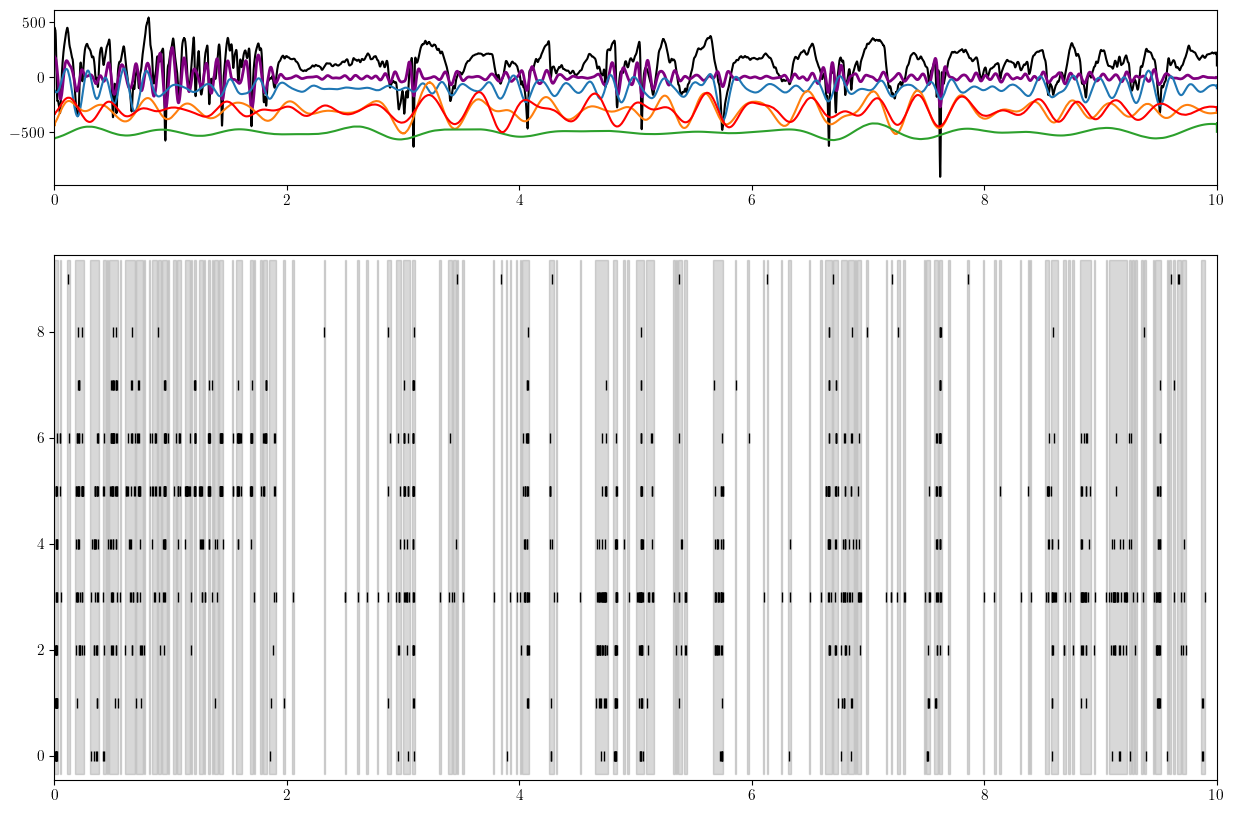

In [25]:
trial =26
plt.rcParams['font.size']=11
x = lfpTrials[trial ,26,:]
sample_rate = 2500
#x = sig3

ii =25
imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
# Visualise the IMFs
factor = 10
from scipy.signal import resample_poly
upsampled = resample_poly(imf[0][:,1], up=factor, down=1)
upsampled2 = resample_poly(imf[0][:,2], up=factor, down=1)
upsampled3 = resample_poly(imf[0][:,3], up=factor, down=1)
upsampled4 = resample_poly(imf[0][:,4], up=factor, down=1)


x_ = lfpTrials[trial,8,:]
imf = emd.sift.mask_sift(x_, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)

upsampled3_th = resample_poly(imf[0][:,3], up=factor, down=1)



time = np.arange(0,25000*10,1)/25000
fig,axes = plt.subplots(2,1, figsize =(15,10),gridspec_kw={'height_ratios': [1, 3]})
axes[0].plot(time,  resample_poly(x, up=factor, down=1)+100, color ='black')
axes[0].plot(time, upsampled, color ='purple', lw =2)

axes[0].plot(time, upsampled2-100)

axes[0].plot(time, upsampled3-300)
axes[0].plot(time, upsampled4-500)

axes[0].plot(time, upsampled3_th-300, color='red')


axes[0].set_xlim(0,10)
Raster_Plot_ava(binspikes[trial,20:,:25000*10].T,mean_interspike_time,fs = 25000,nsize = 7,ax = axes[1])
axes[1].set_xlim(0,10)



(10.0, (28, 30, 250000))

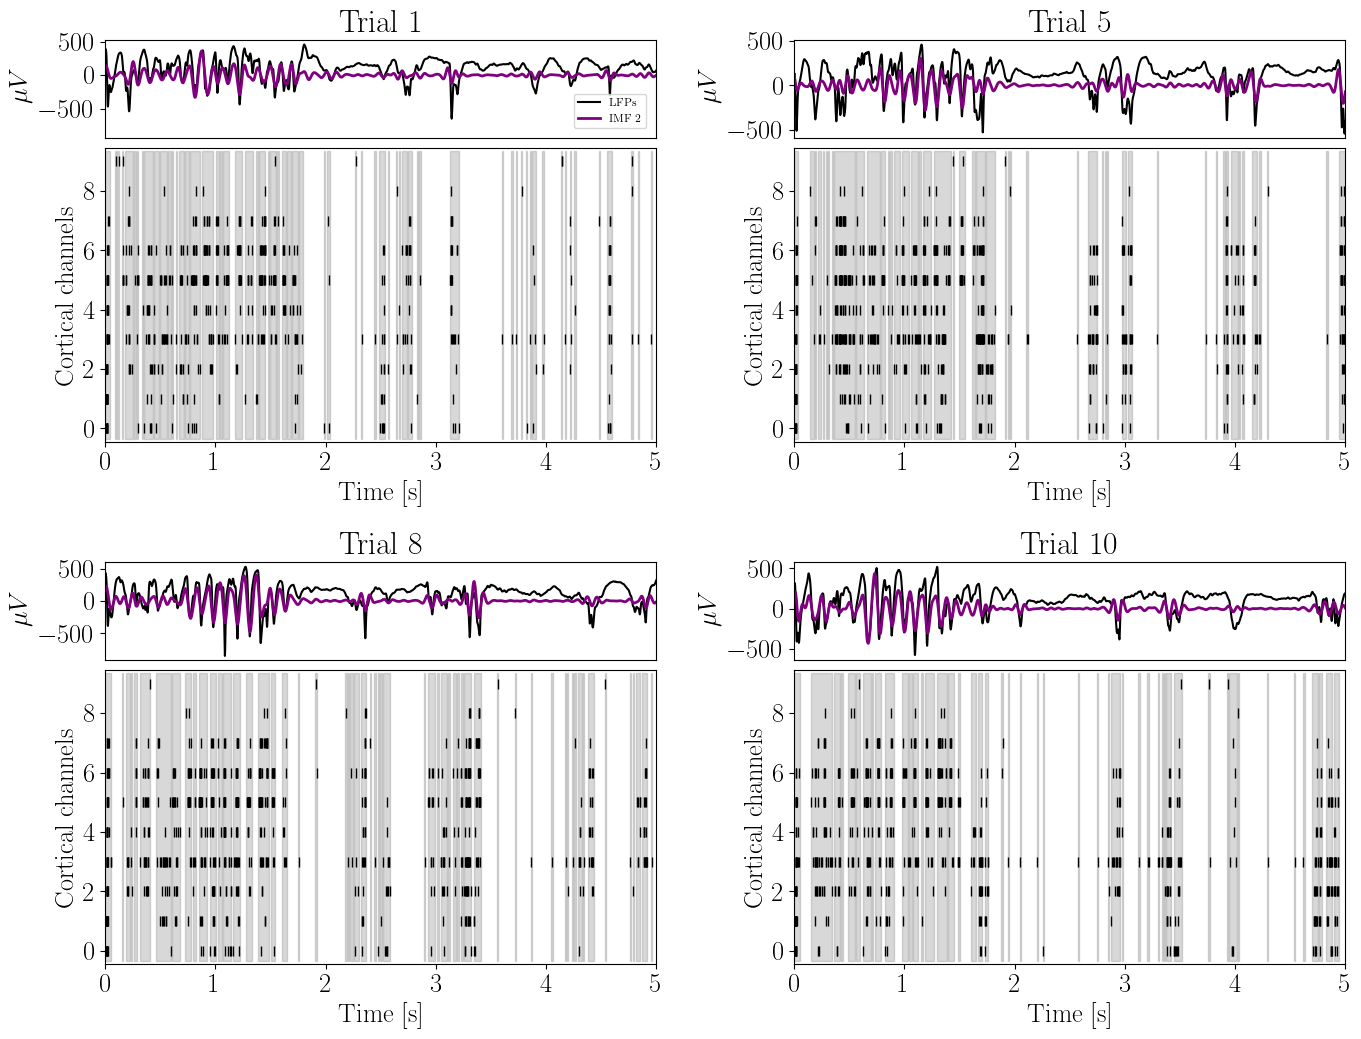

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
import emd
import matplotlib.gridspec as gridspec

plt.rcParams['font.size'] = 19

sample_rate = 2500
factor = 10
ii = 30

trials =[1,5,8,10]

fig = plt.figure(figsize=(16, 12))
outer = gridspec.GridSpec(2, 2, wspace=0.25, hspace=0.3)

for idx, trial in enumerate(trials):

    # --- crea sub-grid (signal sopra, raster sotto) ---
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer[idx],
        height_ratios=[1, 3],
        hspace=0.05
    )

    ax_signal = plt.Subplot(fig, inner[0])
    ax_raster = plt.Subplot(fig, inner[1])

    fig.add_subplot(ax_signal)
    fig.add_subplot(ax_raster)

    # =========================
    # --- SEGNALE PRINCIPALE ---
    # =========================
    x = lfpTrials[trial, 26, :]
    imf = emd.sift.mask_sift(
        x, max_imfs=9,
        mask_freqs=ii/sample_rate,
        ret_mask_freq=True
    )

    up1 = resample_poly(imf[0][:, 1], up=factor, down=1)
    #up2 = resample_poly(imf[0][:, 2], up=factor, down=1)
    #up3 = resample_poly(imf[0][:, 3], up=factor, down=1)
    #up4 = resample_poly(imf[0][:, 4], up=factor, down=1)

    # --- TH ---
    x_ = lfpTrials[trial, 8, :]
    imf_th = emd.sift.mask_sift(
        x_, max_imfs=9,
        mask_freqs=ii/sample_rate,
        ret_mask_freq=True
    )

    up3_th = resample_poly(imf_th[0][:, 3], up=factor, down=1)

    # --- TIME ---
    time = np.arange(0, len(x) * factor) / (sample_rate * factor)

    # --- PLOT SIGNAL ---
    ax_signal.plot(time, resample_poly(x, up=factor, down=1) + 100, color='black', label ='LFPs')
    ax_signal.plot(time, up1, color='purple', lw=2, label ='IMF 2')
    #ax_signal.plot(time, up2 - 100)
    #ax_signal.plot(time, up3 - 300)
    #ax_signal.plot(time, up4 - 500)
    #ax_signal.plot(time, up3_th - 300, color='red')
    if idx == 0:
        ax_signal.legend(fontsize = 8, loc = (0.85,0.1))
    ax_signal.set_xlim(0, 5)
    ax_signal.set_title(f"Trial {trial}")
    ax_signal.set_xticks([])  # pulizia visiva
    ax_signal.set_ylabel(r"$\mu V$")  # pulizia visiva

    # --- RASTER ---
    Raster_Plot_ava(
        binspikes[trial, 20:, :25000*10].T,
        mean_interspike_time,
        fs=25000,
        nsize=7,
        ax=ax_raster
    )

    ax_raster.set_xlim(0, 5)
    ax_raster.set_ylabel('Cortical channels')
    ax_raster.set_xlabel('Time [s]')
    
plt.tight_layout()
#plt.show()
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures/'
plt.savefig(path_figures +'Figure_ava_oscill.jpg', dpi = 300, bbox_inches = 'tight')
#plt.savefig(path_figures +'Figure3.tif', dpi = 300, bbox_inches = 'tight');

In [69]:
ii

30

(0.1, 1.0)

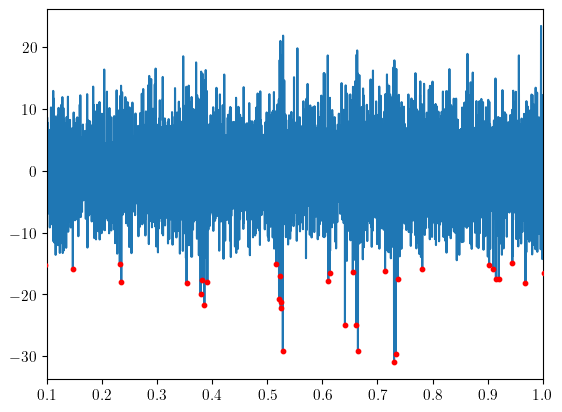

In [34]:
# time series
signal = spikesTrials[10,25]
plt.plot(time, 
         signal)
binary_signal = binspikes[10,25]
# indici dove il segnale è "attivo" (binario = 1)
idx = np.where(binary_signal == 1)[0]
time = np.arange(0,25000*10,1)/25000
# punti rossi sovrapposti
plt.scatter(time[idx], signal[idx], color='red', s=10, zorder=3)
plt.xlim(0.1,1)

(0.0, 2.5)

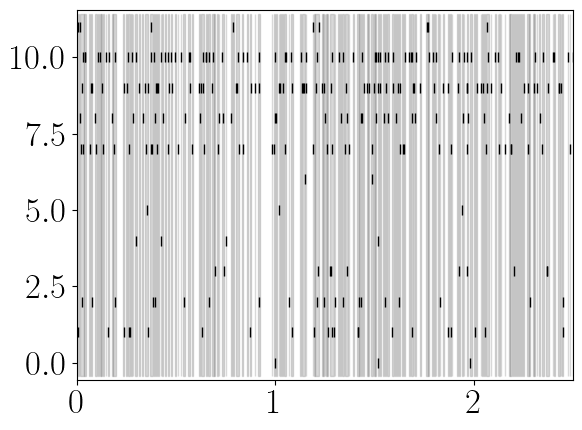

In [73]:
Raster_Plot_ava(binspikes[0,:12,:25000*10].T,mean_interspike_time,fs = 25000,nsize = 7,)
plt.xlim(0,2.5)

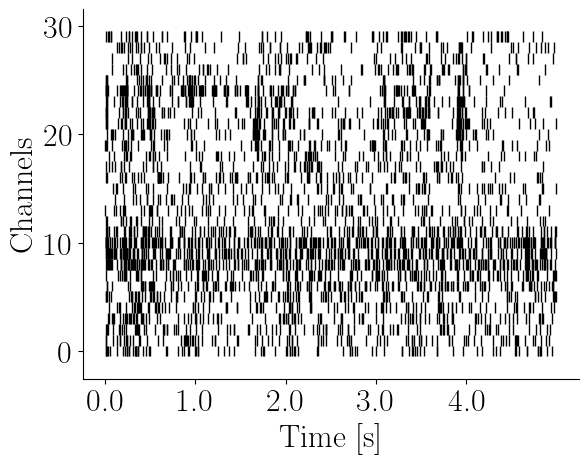

In [111]:

pos = []
trial = 12
for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])

pos = np.asarray(pos)
plt.eventplot(pos, color='black',linewidth=1.);
plt.xlabel('Time [s]')
plt.xticks(np.arange(0,25000*5,25000), labels = np.arange(0,25000*5,25000)/25000)
plt.ylabel('Channels');


## PAC with firing rate

In [58]:
#binspikes.shape, lfpTrials.shape
start_rest,end_rest=2,T
restspikes = concatenat_spikes(binspikes[:,20:],start_rest,end_rest,nTrials, fs=25000)
print(binspikes.shape,restspikes.shape)
S_shape_ = np.zeros((restspikes.shape[0]))

prova_n = restspikes
#inspikes[0].T
N = prova_n.shape[0]
for ch in range(prova_n.shape[1]):
    S_shape_ += prova_n[:,ch]
where_spikes = np.where(S_shape_ != 0)
interspike_time = (where_spikes - np.roll(where_spikes,1))
interspike_time = np.delete(interspike_time,0) # remove the first element
mean_interspike_time = np.sum(interspike_time)/len(interspike_time)
mean_interspike_time = int(round(mean_interspike_time))
mean_interspike_time

(58, 30, 125000) (4425000, 10)


134

In [59]:
#plt.hist(durations, bins=50);
lfpTrials.shape

(59, 30, 12500)

In [93]:
np.random.randint(0,binspikes.shape[0]), binspikes.shape[0]

(1, 28)

In [101]:
start_rest

2

In [60]:
## Compute density
## NULL MODEL:: 
## CORTEX
from scipy.ndimage import gaussian_filter1d

aas =[]
aas2 =[]
from numpy import *
ref_ch = 25
cortex = 20

factor = 10
fs = 25000/factor
for s in range(binspikes.shape[0]):

    s1 = np.random.randint(0,binspikes.shape[0])
    #check
    if (s1 == s):
        s1 = np.random.randint(0,binspikes.shape[0])
        print(s1 ==s)
        
    v = emd.sift.mask_sift(lfpTrials[s1,ref_ch,int(fs)*2:], mask_freqs= 30./fs, max_imfs=5, )
    from scipy.signal import resample_poly
    upsampled = resample_poly(v, up=factor, down=1)
    low = 3
    IP, IF, IA = emd.spectra.frequency_transform(upsampled[:,3] + upsampled[:,4], fs*100, 'nht')
    phi = IP[:,0]
    coef = 5
    amp = gaussian_filter1d(compute_density(binspikes[s,cortex:,int(fs*factor)*2:].T, mean_interspike_time,coef),150)
    p_bins = arange(0, 2*pi, 0.1)
    a_mean = zeros(size(p_bins)-1)
    p_mean = zeros(size(p_bins)-1)
    for k in range(size(p_bins)-1):     #For each phase bin,
        pL = p_bins[k]                  #... lower phase limit,
        pR = p_bins[k+1]                #... upper phase limit.
        indices=(phi>=pL) & (phi<pR)    #Find phases falling in bin,
        a_mean[k] = mean(amp[indices])  #... compute mean amplitude,
        p_mean[k] = mean([pL, pR])      #... save center phase.
    aas.append(a_mean)

False
False


In [61]:
## Compute density

## CORTEX
from scipy.ndimage import gaussian_filter1d

aastrue =[]
aas2 =[]
from numpy import *
ref_ch = 25
cortex = 20

factor = 10
fs = 25000/factor
for s in range(binspikes.shape[0]):

    
    v = emd.sift.mask_sift(lfpTrials[s,ref_ch,int(fs)*2:], mask_freqs= 30./fs, max_imfs=5, )
    from scipy.signal import resample_poly
    upsampled = resample_poly(v, up=factor, down=1)
    low = 3
    IP, IF, IA = emd.spectra.frequency_transform(upsampled[:,3] + upsampled[:,4], fs*100, 'nht')
    phi = IP[:,0]
    coef = 5
    amp = gaussian_filter1d(compute_density(binspikes[s,cortex:,int(fs*factor)*2:].T, mean_interspike_time,coef),150)
    p_bins = arange(0, 2*pi, 0.1)
    a_mean = zeros(size(p_bins)-1)
    p_mean = zeros(size(p_bins)-1)
    for k in range(size(p_bins)-1):     #For each phase bin,
        pL = p_bins[k]                  #... lower phase limit,
        pR = p_bins[k+1]                #... upper phase limit.
        indices=(phi>=pL) & (phi<pR)    #Find phases falling in bin,
        a_mean[k] = mean(amp[indices])  #... compute mean amplitude,
        p_mean[k] = mean([pL, pR])      #... save center phase.
    aastrue.append(a_mean)


In [63]:
a_mean.shape

(62,)

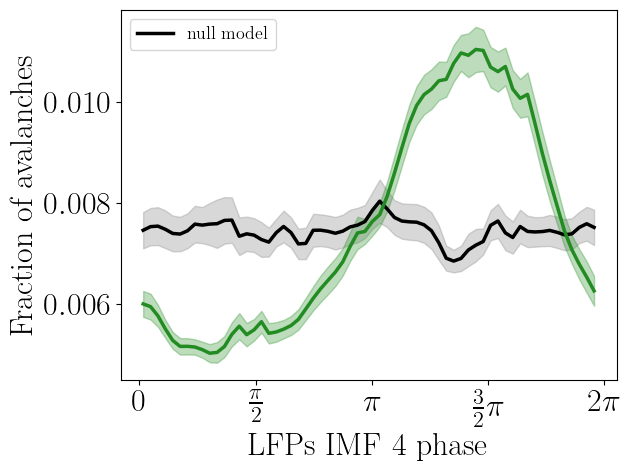

In [62]:
path_pac = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures/pac/'
plt.rcParams['font.size'] = 23

aasmean = np.mean(np.asarray(aas),0)
aas = np.asarray(aas)
aas2 = aas
coef = 5

#ax[1,1].plot(p_mean, aas2mean, color='r')
#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
plt.fill_between(p_mean,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='gray', alpha =.3)# label ='null model')
plt.plot(p_mean, aasmean, color='black',label ='null model', lw = 2.5,)


aasmean = np.mean(np.asarray(aastrue),0)
aastrue = np.asarray(aastrue)
aas2 = aastrue
coef = 5

#ax[1,1].plot(p_mean, aas2mean, color='r')
#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
plt.fill_between(p_mean,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='forestgreen', alpha =.3)
plt.plot(p_mean, aasmean, color ='forestgreen', lw = 2.5)
plt.xlabel('LFPs IMF 4 phase')
plt.ylabel('Fraction of avalanches');

plt.xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi], labels=(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"]));
plt.legend(fontsize = 13);

label ='pc'#'maxtor
#plt.savefig(path  + f'pac_avalanches_rat_{label}{rat}.jpg', dpi = 300, bbox_inches ='tight');

'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio'

In [28]:
rat

1

# Figure 3

In [64]:

import powerlaw as pwl
import numpy as np
from powerlaw_fit import *
from stats import *
from power import *
from matplotlib import cm
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm

import pandas as pd
#from numba import njit
from statsmodels.regression import linear_model as sm

matplotlib.rc('font', **{'family':'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [65]:
plt.rcParams['font.size'] = 23

Calculating best minimal value for power law fit
Nbins estimated are are 20
Alpha is 3.699831099926488
11.0
Calculating best minimal value for power law fit
Nbins estimated are are 14
Alpha is 3.285918481984353
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Prediction from crackling noise relation: delta =  0.8466772066997988 +- 0.029695767176947555
Fit from of average size given duration points: delta =  1.0948682461382482 +- 0.023124924206280064
4.0


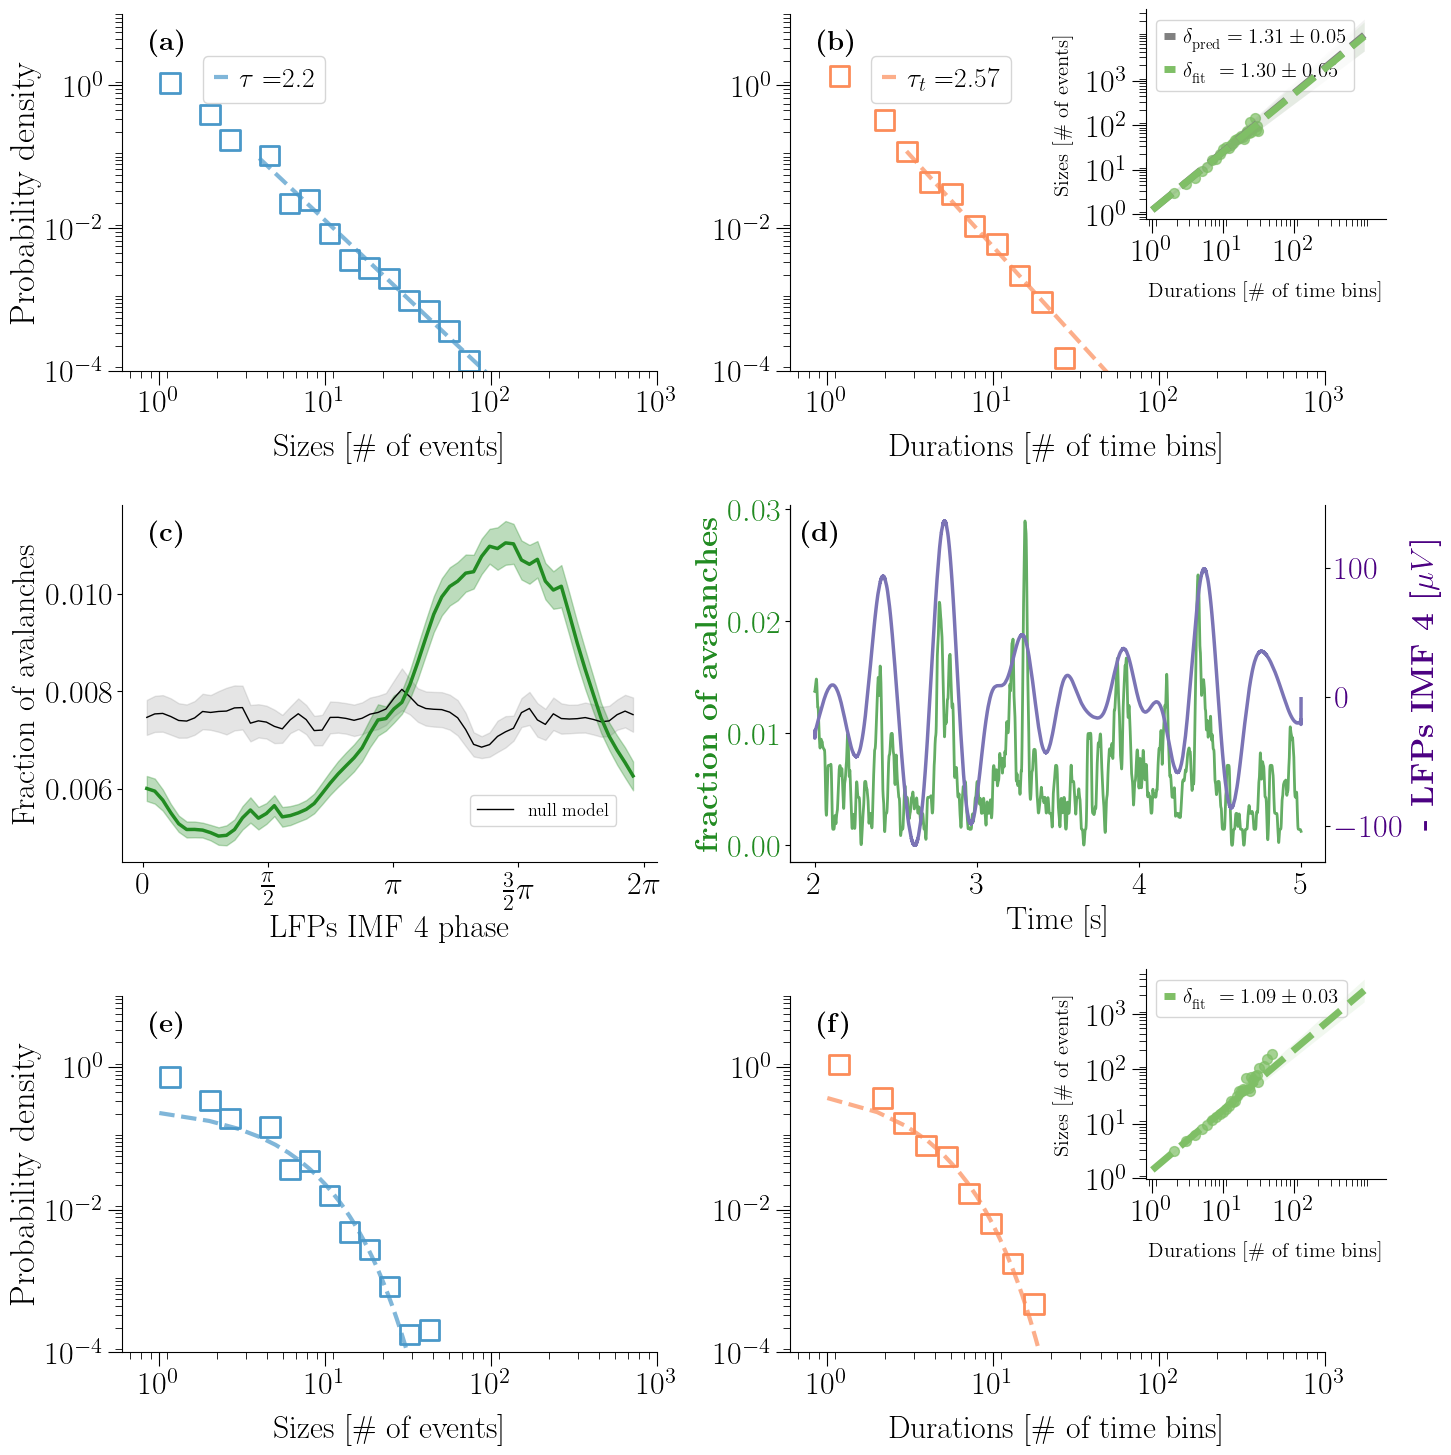

In [106]:
# import emd
sample_rate = 25000


plt.rcParams['axes.spines.top']= False
plt.rcParams['axes.spines.right']= False
expo = False
if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(3,2,figsize =(15,15))
left, bottom, width, height  =[0.78, 0.84,0.16, 0.14]

ax3 = fig.add_axes([left, bottom, width, height])
#expo = True

color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0,0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_par[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_par[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo,plot_param=2)
   
    
    ax[0,0].set_xlim(0.6,1000)
    ax[0,0].set_ylim(0.0001,10)
    ax[0,0].set_xticks(np.logspace(0,3,4))

    ax[0,0].set_xlabel(r'Sizes [\# of events]', fontsize = 23, labelpad = 10)
    
    plot_av_statistics(ax[0,1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_par[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_par[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo, plot_param=2)
    
  
    ax[0,1].set_xlim(0.6,500)
    ax[0,1].set_ylim(0.0001,10)
    ax[0,1].set_xticks(np.logspace(0,3,4))

    ax[0,1].set_xlabel(r'Durations [\# of time bins]', fontsize = 23, labelpad = 10)
    
    xmax = 1000

    
    plot_crackling_noise(ax3, extrinsic_par[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz)
  
    ax3.legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 15, loc = 'upper left')


    ax3.set_xlim(0.8,2000)
    ax3.set_xticks([1,10,100])
    ax3.set_yticks([1,10,100,1000])
    
if not expo: 
    ax[0,0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))
    ax[0,1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))
#ax[2].remove()


ax[0,0].set_ylabel('Probability density', fontsize = 25)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for ax_ in [ax[0,0],ax[0,1],ax3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.xaxis.set_minor_locator(locmin)
    ax_.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.yaxis.set_minor_locator(locmin)
    ax_.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax_.tick_params(length = 5, which = 'minor')
    ax_.tick_params(length = 10)




#from scipy import ndimage
mean_interspike_time = 140
coef = 5


aasmean = np.mean(np.asarray(aas),0)
aas = np.asarray(aas)
aas2 = aas
coef = 5

#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
ax[1,0].fill_between(p_mean,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='gray', alpha =.2)
ax[1,0].plot(p_mean, aasmean, color ='black', lw = 1, label='null model')
ax[1,0].set_xlabel('LFPs IMF 4 phase')
ax[1,0].set_ylabel('Fraction of avalanches');


aasmean = np.mean(np.asarray(aastrue),0)
aastrue = np.asarray(aastrue)
aas2 = aastrue
coef = 5

#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
ax[1,0].fill_between(p_mean,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='forestgreen', alpha =.3)
ax[1,0].plot(p_mean, aasmean, color ='forestgreen', lw = 2.5)
ax[1,0].set_xlabel('LFPs IMF 4 phase')
ax[1,0].set_ylabel('Fraction of avalanches');
ax[1,0].legend(fontsize = 13, loc =(0.65,0.1));

plt.rcParams['axes.spines.right']= True
t = np.arange(0,25000*3,1)/25000 + 2






trial_ = 56







v = emd.sift.mask_sift(lfpTrials[trial_,25,int(sample_rate/factor)*2:], mask_freqs= 30./fs, max_imfs=5, )
from scipy.signal import resample_poly




upsampled = resample_poly(v, up=factor, down=1)
amp = compute_density(binspikes[trial_,20:,sample_rate*2:].T, mean_interspike_time,coef ## attenzione
                    )
ax[1,1].plot(t,gaussian_filter1d(amp,50), color = 'forestgreen', lw = 2,alpha = .7)

ax[1,1].set_ylabel(r'\textbf{fraction of avalanches} ', color='forestgreen',)  # we already handled the x-label with ax1

ax[1,1].set_xlabel('Time [s]')
ax[1,1].tick_params(axis='y', labelcolor='forestgreen',)

ax2 = ax[1,1].twinx() # instantiate a second Axes that shares the same x-axis

color = 'indigo'
#ax2.set_ylabel('Low frequency oscillation ', color=color)  # we already handled the x-label with ax1#

#ax2.tick_params(axis='y', labelcolor=color)
_,_,IA_low=  emd.spectra.frequency_transform(-(upsampled[:,3] + upsampled[:,4]), sample_rate, 'nht')
ax2.tick_params(axis='y', labelcolor=color)

#ax2.plot(t, IA_low, color = 'indigo', lw = 2, alpha = 1)
ax2.plot(t, -(upsampled[:,3]), color = cm.get_cmap('Purples')(0.65), lw = 2.5,alpha = 1)
ax2.set_ylabel(r'\textbf{- LFPs IMF 4 [$\mu V$]}', color =color)
plt.rcParams['axes.spines.right']= False



##############################################################################################################################################################
################################################################ THALAMUS AVALANCHES #########################################################################

left, bottom, width, height  = [0.78, 0.2,0.16, 0.14]

ax3 = fig.add_axes([left, bottom, width, height])
#ax4 = fig.add_axes([left, bottom, width, height])


s = [sizesT]
d = [durationsT]
extrinsic_parT = []
h = 0

temp = []
sizes = s[h]
durations = d[h]

xm = max(sizes) if h == 0 else max(sizes)
expo = True



if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(sizes,1,4, xm,'default', expo)
print(xmin)

temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
xm2 = max(durations) if h == 0 else max(durations)

centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(durations,1,4,xm2,'default', expo)
temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
a, b, c, x, inter, pred, errpred, fit, errfit = scaling_new(sizes,durations,1,4,4,
                                                            'default','default','default',
                                                            'default',xm,xm2,'default','default',50,50)
print(xmin)
temp.append([sizes, durations, a, b, c, x, inter, pred, errpred, fit, errfit])
extrinsic_parT.append(temp)


color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[2,0], extrinsic_parT[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_parT[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_parT[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[2,0].set_xlim(0.6,1000)
    ax[2,0].set_ylim(0.0001,10)
    ax[2,0].set_xticks(np.logspace(0,3,4))

    ax[2,0].set_xlabel(r'Sizes [\# of events]', fontsize = 23, labelpad = 10)
    
    plot_av_statistics(ax[2,1], extrinsic_parT[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_parT[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_parT[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[2,1].set_xlim(0.6,500)
    ax[2,1].set_ylim(0.0001,10)
    ax[2,1].set_xticks(np.logspace(0,3,4))

    ax[2,1].set_xlabel(r'Durations [\# of time bins]', fontsize = 23, labelpad = 10)
    
    xmax = 1000

    
    plot_crackling_noise(ax3, extrinsic_parT[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz)
  
    ax3.legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 15, loc = 'upper left')


    ax3.set_xlim(0.8,2000)
    ax3.set_xticks([1,10,100])
    ax3.set_yticks([1,10,100,1000])
    
if not expo: 
    ax[2,0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))
    ax[2,1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))
#ax[2].remove()


ax[2,0].set_ylabel('Probability density', fontsize = 25)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for ax_ in [ax[2,0],ax[2,1],ax3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.xaxis.set_minor_locator(locmin)
    ax_.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.yaxis.set_minor_locator(locmin)
    ax_.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax_.tick_params(length = 5, which = 'minor')
    ax_.tick_params(length = 10)










ax[1,0].set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax[1,0].set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])


ax[1,0].annotate('\\textbf{(c)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[1,1].annotate('\\textbf{(d)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.02,0.9), textcoords='axes fraction')



ax[0,0].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[0,1].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')
ax[2,0].annotate('\\textbf{(e)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[2,1].annotate('\\textbf{(f)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')

plt.tight_layout()
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures/'
plt.savefig(path_figures +'Figure3.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig(path_figures +'Figure3.tif', dpi = 300, bbox_inches = 'tight');

In [99]:
soglia

3

## Avalanches after evoked activity

In [74]:
start_stim, end_stim = 0,2
restspikes = concatenat_spikes(binspikes[:,20:],start_stim, end_stim, nTrials, fs = sample_rate)
binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)
len(sizes)

4104

In [63]:
s = [sizes]
d = [durations]

In [64]:
extrinsic_par = []
h = 0

temp = []
sizes = s[h]
durations = d[h]

xm = max(sizes) if h == 0 else max(sizes)


#fit = pwl.Fit(sizes,xmin = (1,xm + 1),xmax = max(sizes),parameter_range={"alpha":[1,4]}, discrete = True)
#exp = fit.power_law.alpha
#errexp = fit.power_law.sigma
#xmin = fit.power_law.xmin



expo = False
centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(sizes,1,4, xm,'default', expo)
print(xmin)

temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
xm2 = max(durations) if h == 0 else max(durations)

centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(durations,1,4,xm2,'default', expo)
temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
a, b, c, x, inter, pred, errpred, fit, errfit = scaling_new(sizes,durations,1,4,4,
                                                            'default','default','default',
                                                            'default',xm,xm2,'default','default')
print(xmin)
temp.append([sizes, durations, a, b, c, x, inter, pred, errpred, fit, errfit])
extrinsic_par.append(temp)

Calculating best minimal value for power law fit
Nbins estimated are are 19
Alpha is 1.7928061341819483
2.0
Calculating best minimal value for power law fit
Nbins estimated are are 13
Alpha is 2.0789270457554894
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Prediction from crackling noise relation: delta =  1.360956362994815 +- 0.04220404492990174
Fit from of average size given duration points: delta =  1.287400952432277 +- 0.02527895666430768
2.0


In [56]:
expo

False

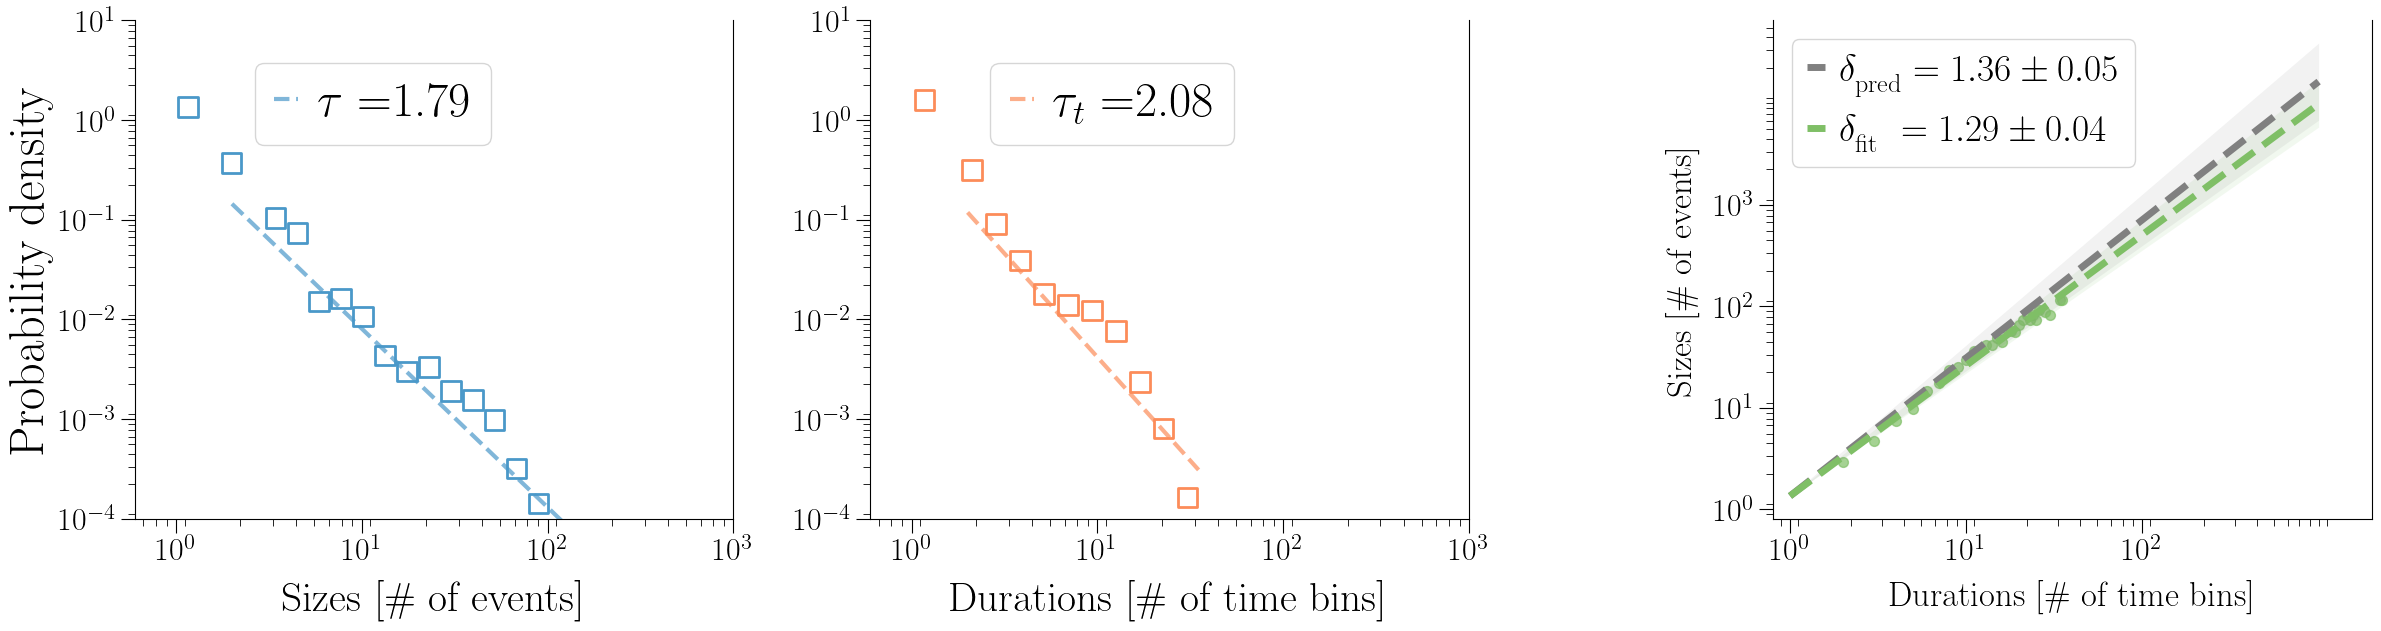

In [67]:
import matplotlib
#expo = True
if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
fig,ax = plt.subplots(1,4,figsize = (24,6.5), gridspec_kw={'width_ratios': [1,1,0.05,1]})
color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_par[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_par[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[0].set_xlim(0.6,1000)
    ax[0].set_ylim(0.0001,10)
    ax[0].set_xticks(np.logspace(0,3,4))

    ax[0].set_xlabel(r'Sizes [\# of events]', fontsize = 30, labelpad = 10)
    
    plot_av_statistics(ax[1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_par[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_par[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[1].set_xlim(0.6,500)
    ax[1].set_ylim(0.0001,10)
    ax[1].set_xticks(np.logspace(0,3,4))

    ax[1].set_xlabel(r'Durations [\# of time bins]', fontsize = 30, labelpad = 10)
    
    xmax = 1000
    plot_crackling_noise(ax[3], extrinsic_par[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz, fontsize = 25)
  
    ax[3].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 27, loc = 'upper left')


    ax[3].set_xlim(0.8,2000)
    ax[3].set_xticks([1,10,100])
    ax[3].set_yticks([1,10,100,1000])
if not expo: 
    ax[0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
    ax[1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
ax[2].remove()


ax[0].set_ylabel('Probability density', fontsize = 35)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for j in [0,1,3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].xaxis.set_minor_locator(locmin)
    ax[j].xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].yaxis.set_minor_locator(locmin)
    ax[j].yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax[j].tick_params(length = 5, which = 'minor')
    ax[j].tick_params(length = 10)


fig.tight_layout(pad = .6,h_pad = 2)
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
plt.show()